### Magnetostatics

Lets solve this non-linear iron core and permanent magnet problem 
- Picard iteration strategy
- Own B-H curve

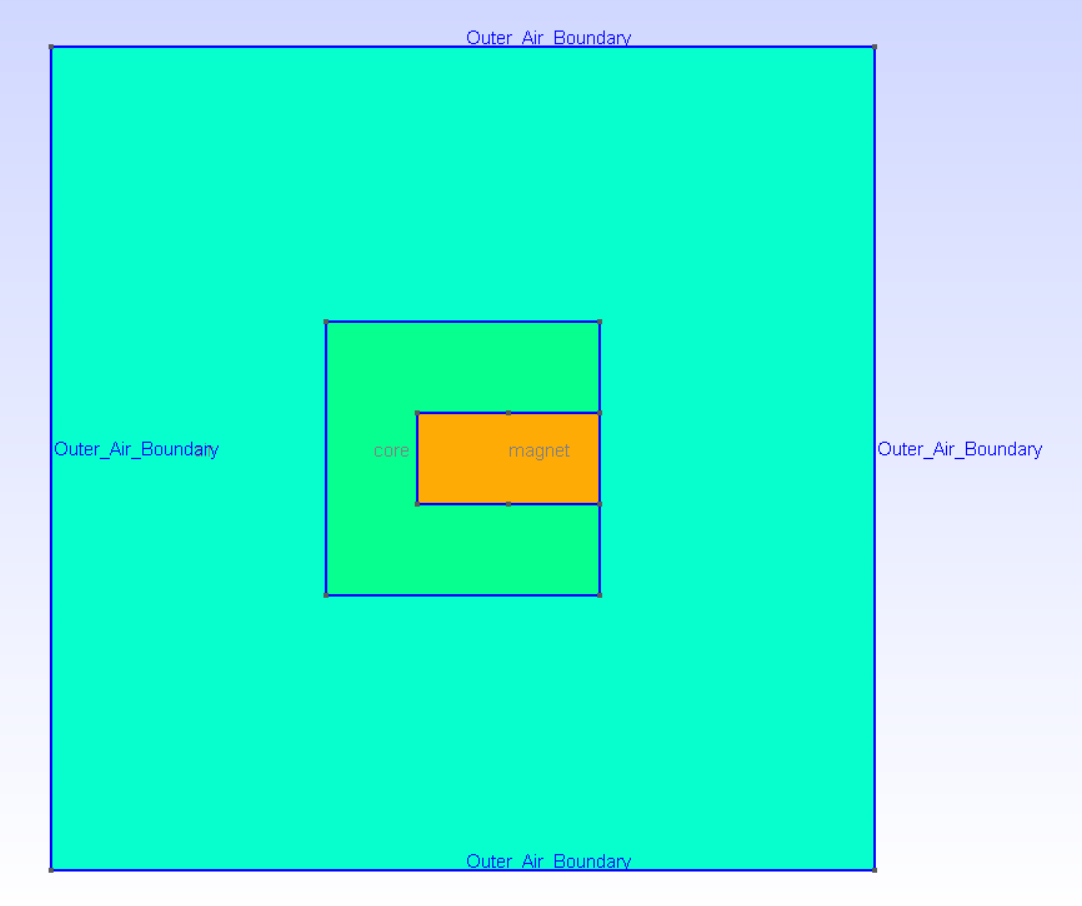

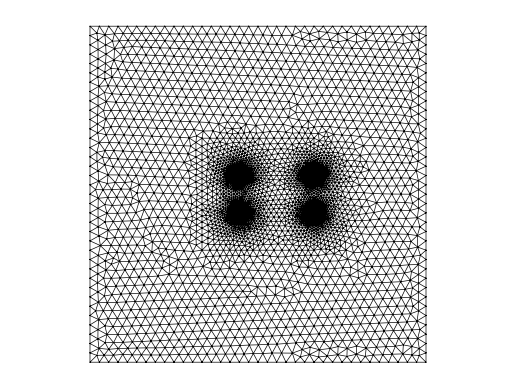

In [87]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


m = meshio.read("mesh/mesh_non_linear_iron.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()

Get triangular elements and first order basis functions. We need to define own basis for each physical group

In [88]:
from skfem import Basis, ElementTriP2

e = ElementTriP2()
basis = Basis(mesh, e)
basis_core = basis.with_elements(mesh.subdomains["core"])
basis_air = basis.with_elements(mesh.subdomains["air"])
basis_magnet = basis.with_elements(mesh.subdomains["magnet"])

print(basis_core)
print(basis_air)
print(basis_magnet)

<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 3344
  Number of DOFs: 18545
  Size: 2889216 B
<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 4390
  Number of DOFs: 18545
  Size: 3792960 B
<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 1466
  Number of DOFs: 18545
  Size: 1266624 B


Bilinear and linear forms, from weak formulation


In [89]:
# Remanent flux. 
Brx = 1.2
Bry = 0

mu0 = 4 * np.pi * 1e-7

mu_air = mu0
mu_pm = mu0

# Non-lniear B-H curve for iron.
data = np.loadtxt("own_BH_curve.txt", comments="#")
H_table = data[:, 0] # [A/m]
B_table = data[:, 1] # [Tesla]

def mu_from_B(B):
    """
    Returns permeability μ(B) [H/m]
    using linear interpolation of the B-H curve.
    """

    B = np.asarray(B)

    H = np.interp(B, B_table, H_table)

    mu = np.empty_like(B)

    mask = B > 1e-12

    mu[mask] = B[mask] / H[mask]
    mu[~mask] = 5000 * mu0      # initial permeability

    return mu


Plot nonlinear iron

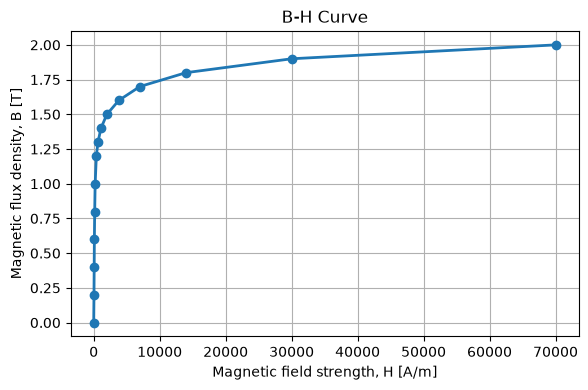

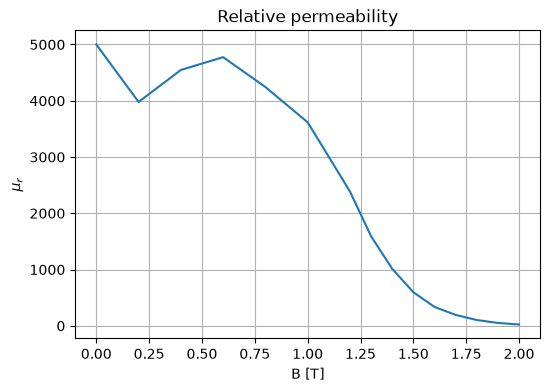

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.plot(H_table, B_table, "o-", linewidth=2, markersize=6)

plt.grid(True)
plt.xlabel("Magnetic field strength, H [A/m]")
plt.ylabel("Magnetic flux density, B [T]")
plt.title("B-H Curve")

plt.tight_layout()
plt.show()

mu = mu_from_B(B_table)
mur = mu / mu0

plt.figure(figsize=(6,4))
plt.plot(B_table, mur)
plt.grid(True)
plt.xlabel("B [T]")
plt.ylabel(r"$\mu_r$")
plt.title("Relative permeability")
plt.show()

In [ ]:

# w.mu little coonfusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))


@LinearForm
def magnet_rhs(v, w):

    Brx = w.Brx
    Bry = w.Bry
    mu = w.mu      # = 1/mu

    return 1/mu * (
        Brx * v.grad[1]
        -
        Bry * v.grad[0]
    )


# mu is now a function of our solution B, not a constant. We have to solve the matrix system iteratively and use initial guess.

# Initial guess of the solution, uh0 = 0
uh0 = basis_core.interpolate(np.zeros(basis_core.N))
Bnorm = np.zeros_like(basis_core.interpolate(np.zeros(basis.N)).grad[0])  # Bnorm = 0 everywhere in iron


alpha = 0.1 # smaller larger alpha takes smaller steps so the convergence is smoother. Takes more time to converge but more stable.
tol = 1e-3  # tolerance when stopping iterations. The smaller the tolerance, the more accurate the solution but takes more time to converge.
max_iter = 1000 # maximum number of iterations. If the solution does not converge, increase this number.

for iteration in range(max_iter):

    # Update permeability
    mu_iron = mu_from_B(Bnorm)

    # Assemble
    S_mat = laplace.assemble(basis_air, mu=mu_air)
    S_mat += laplace.assemble(basis_magnet, mu=mu_air)
    S_mat += laplace.assemble(basis_core, mu=mu_iron)

    b = magnet_rhs.assemble(
        basis_magnet,
        Brx=-Brx,
        Bry=Bry,
        mu=mu_pm,
    )

    S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())
    A_z = solve(S_mat, b)

    # Evaluate B in the iron only
    uh_core = basis_core.interpolate(A_z)

    Bx = uh_core.grad[1]
    By = -uh_core.grad[0]

    B_new = np.sqrt(Bx**2 + By**2)

    # Convergence test (before relaxation)
    rel_change = (
        np.linalg.norm(B_new - Bnorm)
        / max(np.linalg.norm(B_new), 1e-15)
    )

    print(f"Iteration {iteration+1}: ΔB = {rel_change:.3e}")

    if rel_change < tol:
        print("Converged.")
        Bnorm = B_new
        break

    # Relaxation. Small alphas take smaller steps so the convergence is smoother. Takes more time to converge but more stable.
    Bnorm = alpha * B_new + (1 - alpha) * Bnorm

else:
    print("Warning: maximum iterations reached.")

Iteration 1: ΔB = 1.000e+00
Iteration 2: ΔB = 9.001e-01
Iteration 3: ΔB = 8.112e-01
Iteration 4: ΔB = 7.332e-01
Iteration 5: ΔB = 6.619e-01
Iteration 6: ΔB = 5.971e-01
Iteration 7: ΔB = 5.378e-01
Iteration 8: ΔB = 4.837e-01
Iteration 9: ΔB = 4.345e-01
Iteration 10: ΔB = 3.899e-01
Iteration 11: ΔB = 3.494e-01
Iteration 12: ΔB = 3.128e-01
Iteration 13: ΔB = 2.798e-01
Iteration 14: ΔB = 2.500e-01
Iteration 15: ΔB = 2.233e-01
Iteration 16: ΔB = 1.992e-01
Iteration 17: ΔB = 1.777e-01
Iteration 18: ΔB = 1.584e-01
Iteration 19: ΔB = 1.413e-01
Iteration 20: ΔB = 1.260e-01
Iteration 21: ΔB = 1.124e-01
Iteration 22: ΔB = 1.004e-01
Iteration 23: ΔB = 8.965e-02
Iteration 24: ΔB = 8.011e-02
Iteration 25: ΔB = 7.162e-02
Iteration 26: ΔB = 6.406e-02
Iteration 27: ΔB = 5.732e-02
Iteration 28: ΔB = 5.131e-02
Iteration 29: ΔB = 4.597e-02
Iteration 30: ΔB = 4.117e-02
Iteration 31: ΔB = 3.690e-02
Iteration 32: ΔB = 3.309e-02
Iteration 33: ΔB = 2.969e-02
Iteration 34: ΔB = 2.664e-02
Iteration 35: ΔB = 2.39

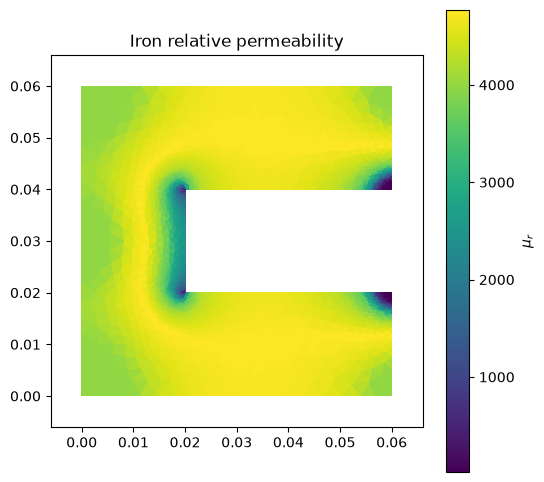

In [92]:
tri_core = mesh.t[:, basis_core.tind].T

triang = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    tri_core
)

mur_elem = mu_iron.mean(axis=1) / mu0

fig, ax = plt.subplots(figsize=(6,6))

pc = ax.tripcolor(
    triang,
    facecolors=mur_elem,
    shading="flat",
    cmap="viridis"
)

# Zoom into the region around the C-core
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)
margin = 0.3 * d  # CHANGE TO ZOOM
ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)

fig.colorbar(pc, ax=ax, label=r"$\mu_r$")
ax.set_aspect("equal")
ax.set_title("Iron relative permeability")
plt.show()

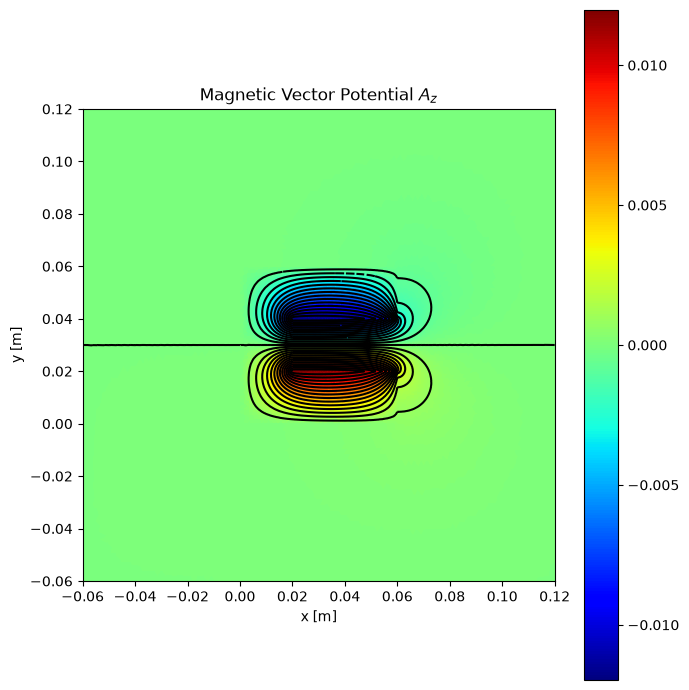

In [93]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

fig, ax = plt.subplots(figsize=(7,7))


plot(
    basis,
    A_z,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

plot(
    basis,
    A_z,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

ax.set_aspect("equal")
ax.set_title(f"Magnetic Vector Potential $A_z$")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.tight_layout()
#from skfem.visuals.matplotlib import draw

#draw(mesh, ax=ax)

plt.show()

Now we compute Bx and By with partial derivatives to plot B field

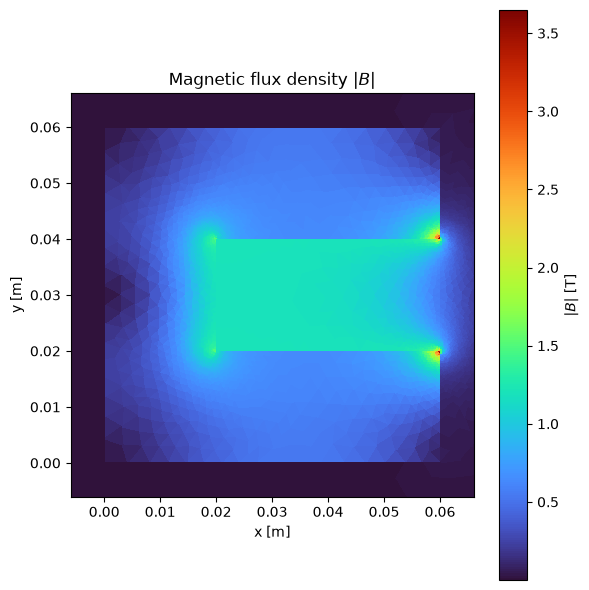

In [118]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri


uh = basis.interpolate(A_z)

# Element-wise B-field (constant within each P2 element)
Bx_elem = uh.grad[1].mean(axis=1)
By_elem = -uh.grad[0].mean(axis=1)
Bmag_elem = np.sqrt(Bx_elem**2 + By_elem**2)

from matplotlib import colors
norm = colors.Normalize(vmin=Bmag_elem.min(), vmax=Bmag_elem.max())

triang = mtri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

fig, ax = plt.subplots(figsize=(6,6))

pc = ax.tripcolor(
    triang,
    facecolors=Bmag_elem,
    shading="flat",
    cmap="turbo",
    norm=norm
)

# Zoom
xmin, ymin = mesh.p.min(axis=1)
xmax, ymax = mesh.p.max(axis=1)
d = max(xmax - xmin, ymax - ymin)
margin = 0.3 * d

ax.set_xlim(xmin + margin, xmax - margin)
ax.set_ylim(ymin + margin, ymax - margin)

ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(r"Magnetic flux density $|B|$")

fig.colorbar(pc, ax=ax, label=r"$|B|$ [T]")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'B field in iron core')

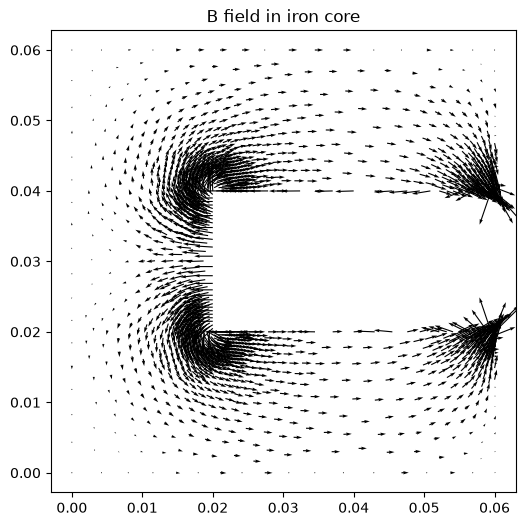

In [117]:
from utils.field_interpolation import eval_B_at_points

# Elements belonging to the basis
tris = mesh.t[:, basis_core.tind]

# Unique vertices of those elements
vertex_ids = np.unique(tris)

# Coordinates
pts = mesh.p[:, vertex_ids].T

Bx, By, _ = eval_B_at_points(
    A_z,
    basis,          # <-- use the FULL basis for evaluation
    pts,
)

plt.figure(figsize=(6,6))
plt.quiver(
    pts[:,0],
    pts[:,1],
    Bx,
    By,
    scale=30
)

plt.axis("equal")
plt.title("B field in iron core")

Verify results point-wise against COMSOL 

[Az] N points           : 289
[Az] Absolute L2 (RMS)  : 7.313718e-06
[Az] Reference RMS norm : 3.904754e-03
[Az] Relative L2 error  : 0.1873%

     x [m]      y [m]         Az_own         Az_ref      abs err  rel err %
6.0200e-02 4.1000e-02  -3.052849e-03  -3.144677e-03   9.1828e-05     2.9201
6.0200e-02 1.7000e-02   2.214249e-03   2.253138e-03  -3.8888e-05     1.7260
6.0200e-02 4.5800e-02  -1.643709e-03  -1.667229e-03   2.3520e-05     1.4107
5.5400e-02 2.1800e-02   7.124998e-03   7.104927e-03   2.0071e-05     0.2825
6.5000e-02 1.7000e-02   1.629964e-03   1.648502e-03  -1.8538e-05     1.1245
6.0200e-02 1.2200e-02   1.385837e-03   1.404008e-03  -1.8171e-05     1.2942
6.5000e-02 4.1000e-02  -1.766671e-03  -1.783464e-03   1.6792e-05     0.9416
6.5000e-02 4.5800e-02  -1.387186e-03  -1.403853e-03   1.6667e-05     1.1872
6.0200e-02 2.1800e-02   3.940081e-03   3.924981e-03   1.5101e-05     0.3847
6.5000e-02 1.2200e-02   1.226147e-03   1.240563e-03  -1.4415e-05     1.1620
5.5400e-02 4.1000e-02

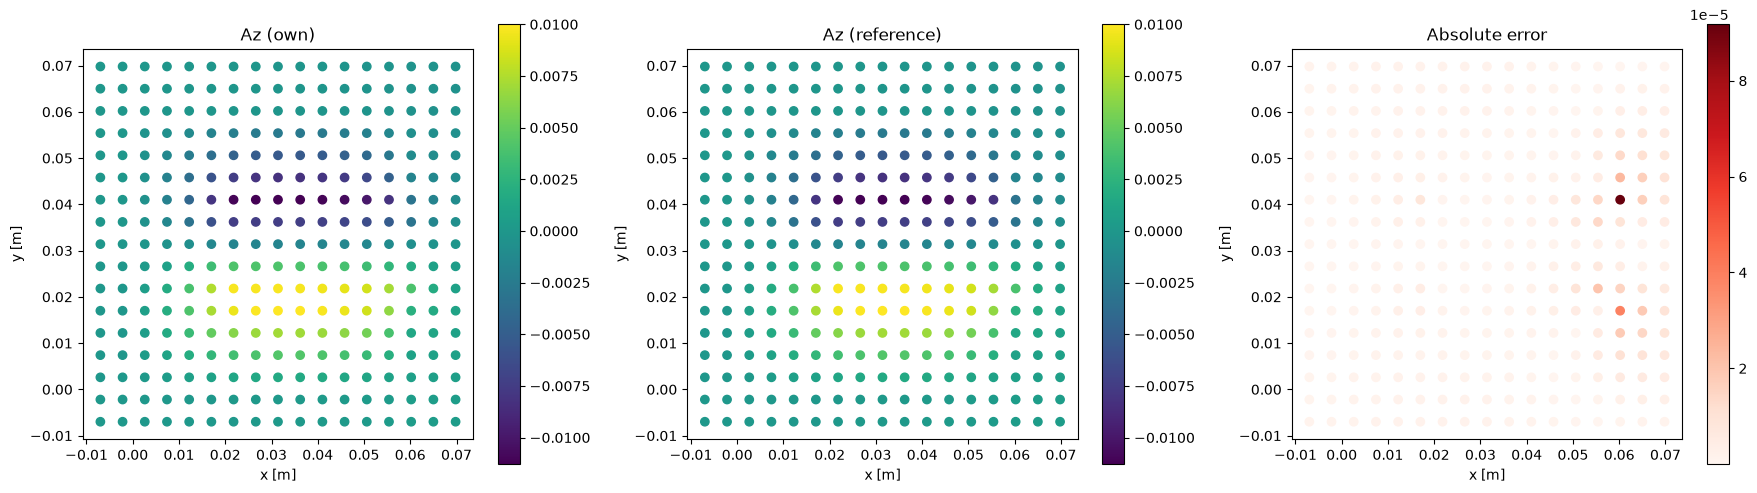

In [ ]:
import numpy as np

# Load COMSOL data
data = np.loadtxt(
    "verification/comsol_Az.txt",
    comments="%"
)

points = data[:, :2]

Az_comsol = data[:, 2]


from utils.field_interpolation import eval_scalar_field_at_points
from utils.field_verification import compare_point_values
# Evaluate your FE solution at the exact same points
Az_python = eval_scalar_field_at_points(
    A_z,
    basis,
    points,
)

compare_point_values(
    Az_python,
    Az_comsol,
    points,
    quantity_name="Az",
);

[Bnorm] N points           : 289
[Bnorm] Absolute L2 (RMS)  : 9.864449e-03
[Bnorm] Reference RMS norm : 5.255271e-01
[Bnorm] Relative L2 error  : 1.8771%

     x [m]      y [m]      Bnorm_own      Bnorm_ref      abs err  rel err %
6.0200e-02 4.1000e-02   6.457269e-01   7.260639e-01  -8.0337e-02    11.0647
6.0200e-02 2.1800e-02   8.633627e-01   8.211493e-01   4.2213e-02     5.1408
5.5400e-02 1.2200e-02   6.575204e-01   6.161597e-01   4.1361e-02     6.7127
5.5400e-02 2.6000e-03   2.780637e-01   2.382208e-01   3.9843e-02    16.7252
5.5400e-02 4.5800e-02   6.947176e-01   7.319379e-01  -3.7220e-02     5.0852
1.7000e-02 2.6000e-03   3.303357e-01   3.631944e-01  -3.2859e-02     9.0471
5.5400e-02 1.7000e-02   9.636111e-01   9.349381e-01   2.8673e-02     3.0668
1.7000e-02 3.1400e-02   1.029316e+00   1.004437e+00   2.4879e-02     2.4769
1.2200e-02 3.1400e-02   6.008376e-01   5.761616e-01   2.4676e-02     4.2828
5.5400e-02 5.0600e-02   4.835690e-01   4.604883e-01   2.3081e-02     5.0122
1.2200e-0

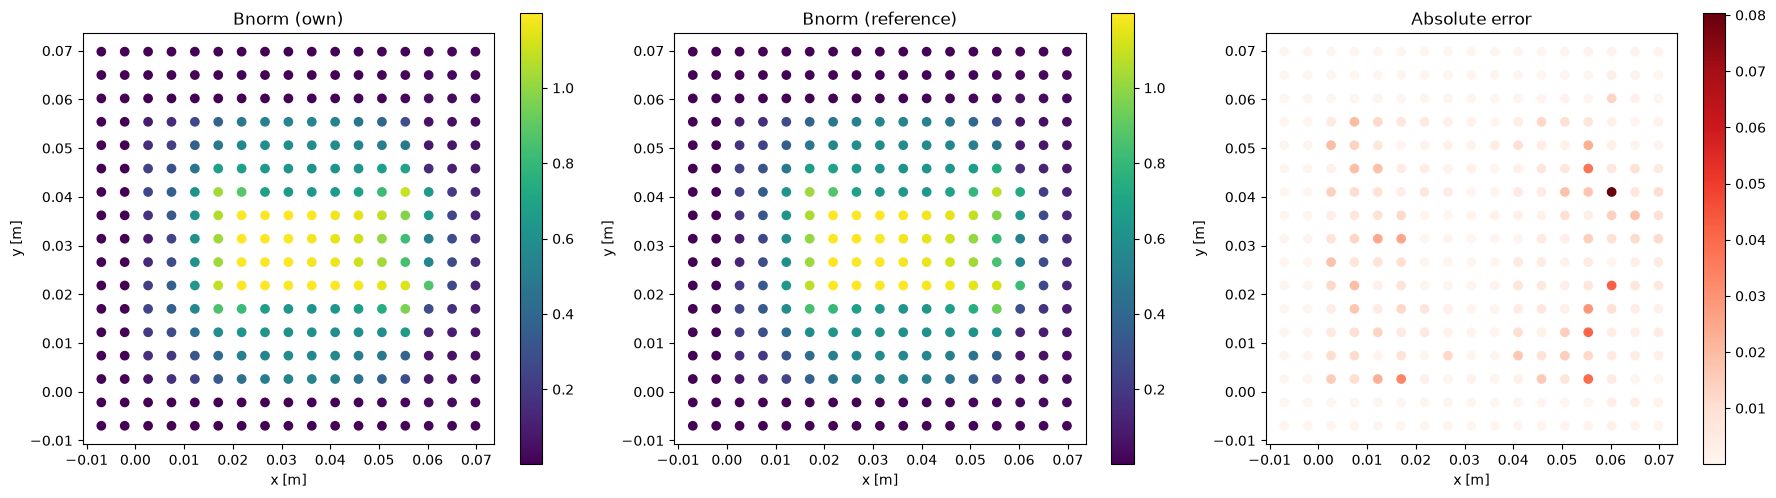

In [120]:
from utils.field_interpolation import eval_B_at_points
from utils.field_verification import compare_point_values

data = np.loadtxt(
    "verification/comsol_Bnorm.txt",
    comments="%"
)

points = data[:, :2]

Bnorm_comsol = data[:, 2]

_, _, Bnorm_python = eval_B_at_points(
    A_z,
    basis,
    points
)

compare_point_values(
    Bnorm_python,
    Bnorm_comsol,
    points,
    quantity_name="Bnorm",
);

Convergence of nonlinear was good and the A and B field were really close to the COMSOL.